**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

*   NOMBRE: Gael Isaac Jurado Romero
*   MATRÍCULA: A01841366


---

En esta actividad trabajarás con el archivo `cleaned_weather.csv`, un extracto del conjunto de datos meteorológicos a lo largo de todo el año 2020 en una estación del Instituto *Max Planck* (Alemania) disponible en Kaggle.

Los datos meteorológicos fueron registrados cada 10 minutos e incluyen los siguientes indicadores:

*   `timestamp`: Fecha y hora de la observación.
*   `p`: Presión atmosférica en milibares (mbar)
*   `T`: Temperatura del aire en grados Celsius (°C)
*   `Tpot`: Temperatura potencial en Kelvin (K)
*   `rh`: Humedad relativa en porcentaje (%)
*   `VPact`: Presión real de vapor en milibares (mbar)
*   `sh`: Humedad específica en gramos por kilogramo (g/kg)
*   `H2OC`: Concentración de vapor de agua en milimoles por mol (mmol/mol) de aire seco
*   `rho`: Densidad del aire en gramos por metro cúbico (g/m³)
*   `wv`: Velocidad del viento en metros por segundo (m/s)
*   `wd`: Dirección del viento en grados (°)
*   `rain`: Precipitación total en milímetros (mm)
*   `raining`: Duración de la lluvia en segundos (s)

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


In [1]:
# Importa las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt

1.	Descarga el archivo: `cleaned_weather.csv` y guarda, en un dataframe (`weather_df`), todos sus registros.
- Determina la dimensionalidad del dataframe y obtén los identificadores de columnas.
- Renombra las columnas para facilitar la interpretación de los indicadores en los ejercicios siguientes:
  - `medicion, presion_atmosferica, temperatura_celsius, temperatura_kelvin, humedad_relativa, presion_vapor, humedad_especifica, concentracion_vapor, densidad_aire, velocidad_viento, direccion_viento, precipitacion_total, duracion_lluvia`
- Muestra los primeros y los últimos 5 registros.
- ¿Hay valores faltantes en el dataframe?





In [2]:
weather_df = pd.read_csv('cleaned_weather.csv')

In [3]:
weather_df.shape

(52696, 13)

El dataframe tiene **52,696 registros (filas)** y **13 columnas**.

In [4]:
weather_df.columns

Index(['timestamp', 'p', 'T', 'Tpot', 'rh', 'VPact', 'sh', 'H2OC', 'rho', 'wv',
       'wd', 'rain', 'raining'],
      dtype='str')

In [5]:
weather_df.columns = ['medicion', 'presion_atmosferica', 'temperatura_celsius', 'temperatura_kelvin',
                      'humedad_relativa', 'presion_vapor', 'humedad_especifica', 'concentracion_vapor',
                      'densidad_aire', 'velocidad_viento', 'direccion_viento', 'precipitacion_total',
                      'duracion_lluvia']
weather_df.head()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
0,01/01/20 0:10,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0
1,01/01/20 0:20,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0
2,01/01/20 0:30,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0
3,01/01/20 0:40,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0
4,01/01/20 0:50,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0


In [6]:
weather_df.tail()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
52691,31/12/20 23:20,978.32,2.28,277.16,80.0,5.76,3.67,5.89,1234.61,0.73,180.6,0.0,0
52692,31/12/20 23:30,978.30,2.13,277.01,83.1,5.92,3.77,6.05,1235.20,0.43,174.0,0.0,0
52693,31/12/20 23:40,978.26,1.99,276.88,82.2,5.80,3.69,5.93,1235.82,0.38,248.9,0.0,0
52694,31/12/20 23:50,978.26,2.07,276.95,81.4,5.77,3.68,5.90,1235.49,0.57,196.6,0.0,0
52695,01/01/21 0:00,978.24,2.01,276.89,82.4,5.82,3.71,5.95,1235.71,0.57,221.3,0.0,0


In [7]:
weather_df.isna().sum()

medicion               0
presion_atmosferica    0
temperatura_celsius    0
temperatura_kelvin     0
humedad_relativa       0
presion_vapor          0
humedad_especifica     0
concentracion_vapor    0
densidad_aire          0
velocidad_viento       0
direccion_viento       0
precipitacion_total    0
duracion_lluvia        0
dtype: int64

**No**, no hay valores faltantes en el dataframe: todas las columnas tienen 0 valores nulos (`NaN`).

2. Determina el tipo de datos que tienen las columnas.
- Cambia la columna `medicion` a datetime utilizando el formato: `%d/%m/%y %H:%M`
- Obtén dos columnas adicionales separando `medicion` en `fecha` y `hora`

In [8]:
weather_df.dtypes

medicion                   str
presion_atmosferica    float64
temperatura_celsius    float64
temperatura_kelvin     float64
humedad_relativa       float64
presion_vapor          float64
humedad_especifica     float64
concentracion_vapor    float64
densidad_aire          float64
velocidad_viento       float64
direccion_viento       float64
precipitacion_total    float64
duracion_lluvia          int64
dtype: object

La columna `medicion` es de tipo texto, `duracion_lluvia` es entera (`int64`) y el resto de los indicadores son numéricos de punto flotante (`float64`). Es necesario convertir `medicion` a datetime.

In [9]:
weather_df['medicion'] = pd.to_datetime(weather_df['medicion'], format='%d/%m/%y %H:%M')
weather_df['fecha'] = weather_df['medicion'].dt.date
weather_df['hora'] = weather_df['medicion'].dt.time
weather_df.head()

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
0,2020-01-01 00:10:00,1008.89,0.71,273.18,86.1,5.54,3.42,5.49,1280.62,1.02,224.3,0.0,0,2020-01-01,00:10:00
1,2020-01-01 00:20:00,1008.76,0.75,273.22,85.2,5.49,3.39,5.45,1280.33,0.43,206.8,0.0,0,2020-01-01,00:20:00
2,2020-01-01 00:30:00,1008.66,0.73,273.21,85.1,5.48,3.39,5.43,1280.29,0.61,197.1,0.0,0,2020-01-01,00:30:00
3,2020-01-01 00:40:00,1008.64,0.37,272.86,86.3,5.41,3.35,5.37,1281.97,1.11,206.4,0.0,0,2020-01-01,00:40:00
4,2020-01-01 00:50:00,1008.61,0.33,272.82,87.4,5.47,3.38,5.42,1282.08,0.49,209.6,0.0,0,2020-01-01,00:50:00


3. Determina la cantidad de valores únicos de cada columna.
- La columna `medicion` tiene un valor menos que el número total de filas del dataframe, lo que indica que hay una fecha duplicada. Identifica cuál es.
- Comprueba si las demás columnas también contienen los mismos valores; si es así, elimina  uno de los registros duplicados.


In [10]:
weather_df.nunique()

medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
fecha                    367
hora                     144
dtype: int64

In [11]:
weather_df[weather_df['medicion'].duplicated(keep=False)]

,medicion,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,fecha,hora
19043,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00
19044,2020-05-12 06:00:00,991.53,-1.57,272.25,96.2,5.24,3.29,5.28,1269.29,1.04,215.4,0.0,0,2020-05-12,06:00:00


In [12]:
weather_df.duplicated().sum()

np.int64(1)

La fecha duplicada es **12/05/2020 06:00**. Los dos registros con esa fecha tienen exactamente los mismos valores en todas las columnas (`duplicated()` detecta 1 fila completamente repetida), por lo que se elimina uno de ellos.

In [13]:
weather_df = weather_df.drop_duplicates()
weather_df.shape

(52695, 15)

4. Imprime nuevamente las cantidad de valores únicos por columna.
- ¿Por qué son 144 horas diferentes?
- La cantidad de combinaciones únicas de fecha y hora no coincide con el número total de mediciones. Aunque no haya valores NaN, esto no garantiza que no se hayan omitido registros. Identifica las fechas en las que faltan mediciones.
- Una vez concluido el análisis de mediciones faltantes, elimina todos los registros que no correspondan al año 2020 y la columna `medicion`.


In [14]:
weather_df.nunique()

medicion               52695
presion_atmosferica     5052
temperatura_celsius     3680
temperatura_kelvin      3836
humedad_relativa        5494
presion_vapor           2059
humedad_especifica      1337
concentracion_vapor     2087
densidad_aire          14826
velocidad_viento         977
direccion_viento        8099
precipitacion_total       42
duracion_lluvia           61
fecha                    367
hora                     144
dtype: int64

**¿Por qué son 144 horas diferentes?** Porque las mediciones se registran cada 10 minutos, es decir, 6 por hora; en un día hay 24 × 6 = **144** horas distintas (de 00:00 a 23:50). La columna `hora` sólo conserva la hora del día, por lo que estos mismos 144 valores se repiten en cada fecha.

In [15]:
mediciones_por_fecha = weather_df.groupby('fecha').size()
mediciones_por_fecha[mediciones_por_fecha != 144]

fecha
2020-01-01    143
2020-05-29    135
2021-01-01      1
dtype: int64

Cada fecha debería tener 144 mediciones. Las fechas en las que faltan mediciones son:

*   **01/01/2020**: 143 mediciones, falta 1 (la de las 00:00, ya que el registro inicia a las 00:10).
*   **29/05/2020**: 135 mediciones, faltan 9.

Además, **01/01/2021** aparece con un solo registro (00:00), el cual no corresponde al año 2020.

In [16]:
weather_df = weather_df[weather_df['medicion'].dt.year == 2020].drop(columns='medicion')
weather_df.shape

(52694, 14)

5. Obtén un dataframe `indicadores_diarios` que sólo almacene el mayor valor de las mediciones por fecha para responder:
- ¿Cuál fue la máxima precipitación y a qué fecha pertenece?
- ¿Cuáles fueron los tres días con las velocidades de viento más altas registradas?
- ¿Cuántos días rebasaron el 90% de humedad relativa y los 30° celsius?

In [17]:
indicadores_diarios = weather_df.drop(columns='hora').groupby('fecha').max()
indicadores_diarios.head()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
fecha,,,,,,,,,,,,
2020-01-01,1008.89,4.58,277.27,95.0,5.81,3.60,5.77,1298.02,1.91,356.9,0.0,0
2020-01-02,1004.16,6.47,279.72,93.9,5.57,3.48,5.58,1304.37,2.67,358.8,0.0,0
2020-01-03,998.45,8.17,281.80,89.3,9.34,5.86,9.39,1266.97,8.79,336.5,0.2,470
2020-01-04,1003.47,6.61,280.15,91.4,8.54,5.36,8.58,1270.10,4.61,354.7,1.0,600
2020-01-05,1009.07,4.43,277.01,85.3,6.44,3.99,6.40,1275.47,3.14,274.6,0.0,0


In [18]:
indicadores_diarios['precipitacion_total'].nlargest(1)

fecha
2020-06-16    11.2
Name: precipitacion_total, dtype: float64

La máxima precipitación fue de **11.2 mm** y pertenece al **16/06/2020**.

In [19]:
indicadores_diarios['velocidad_viento'].nlargest(3)

fecha
2020-02-10    13.77
2020-02-16    13.00
2020-02-09    12.52
Name: velocidad_viento, dtype: float64

Los tres días con las velocidades de viento más altas fueron:

1.   **10/02/2020**: 13.77 m/s
2.   **16/02/2020**: 13.00 m/s
3.   **09/02/2020**: 12.52 m/s

In [20]:
indicadores_diarios[(indicadores_diarios['humedad_relativa'] > 90) &
                    (indicadores_diarios['temperatura_celsius'] > 30)][['humedad_relativa', 'temperatura_celsius']]

,humedad_relativa,temperatura_celsius
fecha,,
2020-08-11,93.8,31.42
2020-08-12,94.4,32.26
2020-08-20,97.1,30.38
2020-08-21,94.7,34.56
2020-09-15,99.9,30.16


**5 días** rebasaron el 90% de humedad relativa y los 30 °C: 11/08/2020, 12/08/2020, 20/08/2020, 21/08/2020 y 15/09/2020.

6. La función `describe()` resume múltiples estadísticas descriptivas. Utiliza esta función para explorar y responder las preguntas sobre las variables en el dataframe de `indicadores_diarios `:
- ¿Cuál es la desviación estándar de la concentración de vapor y qué indica?
- ¿Cuál es la mediana de la presión atmosférica y qué significa?
- ¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?

In [21]:
indicadores_diarios.describe()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia
count,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000,366.000000
mean,992.977842,15.343770,289.431667,90.886530,11.409454,7.214016,11.539180,1232.622814,5.245164,317.673689,0.314208,240.382514
std,8.543447,7.850339,7.942175,9.201588,4.507555,2.872647,4.573267,32.702446,2.097012,50.611324,0.979721,273.840002
min,959.900000,-0.120000,273.460000,55.440000,3.320000,2.050000,3.290000,1167.050000,1.570000,69.570000,0.000000,0.000000
25%,988.015000,8.840000,282.732500,85.400000,7.647500,4.832500,7.742500,1207.590000,3.662500,279.075000,0.000000,0.000000
50%,993.300000,15.060000,289.160000,93.250000,10.715000,6.705000,10.735000,1231.455000,4.880000,346.650000,0.000000,0.000000
75%,998.432500,21.695000,295.957500,99.900000,14.462500,9.180000,14.685000,1256.057500,6.495000,357.300000,0.200000,600.000000
max,1020.070000,34.800000,309.130000,100.000000,24.160000,15.400000,24.530000,1318.520000,13.770000,360.000000,11.200000,600.000000


*   **¿Cuál es la desviación estándar de la concentración de vapor y qué indica?** Es de **4.57 mmol/mol**, con una media de 11.54 mmol/mol. Indica que los valores máximos diarios se alejan en promedio 4.57 mmol/mol de la media, una dispersión considerable (cerca del 40% de la media) que refleja que la cantidad de vapor de agua en el aire cambia mucho a lo largo del año (de 3.29 a 24.53 mmol/mol).
*   **¿Cuál es la mediana de la presión atmosférica y qué significa?** Es de **993.30 mbar**. Significa que la mitad de los días registró una presión máxima menor o igual a 993.30 mbar y la otra mitad una mayor. Al ser muy cercana a la media (992.98 mbar), la distribución de la presión es aproximadamente simétrica.
*   **¿Cuál es el tercer cuartil de la duración de la lluvia y cómo se interpreta?** Es de **600 s**. El 75% de los días tuvo una duración máxima de lluvia de 600 s o menos. Como 600 s (10 minutos) es también el valor máximo, equivale a que llovió durante un intervalo de medición completo; y como la mediana es 0 s, al menos la mitad de los días no llovió, mientras que al menos el 25% de los días tuvo lluvia durante un intervalo completo de 10 minutos.

7.	Dibuja un histograma para cada una de las columnas de `indicadores_diarios`.

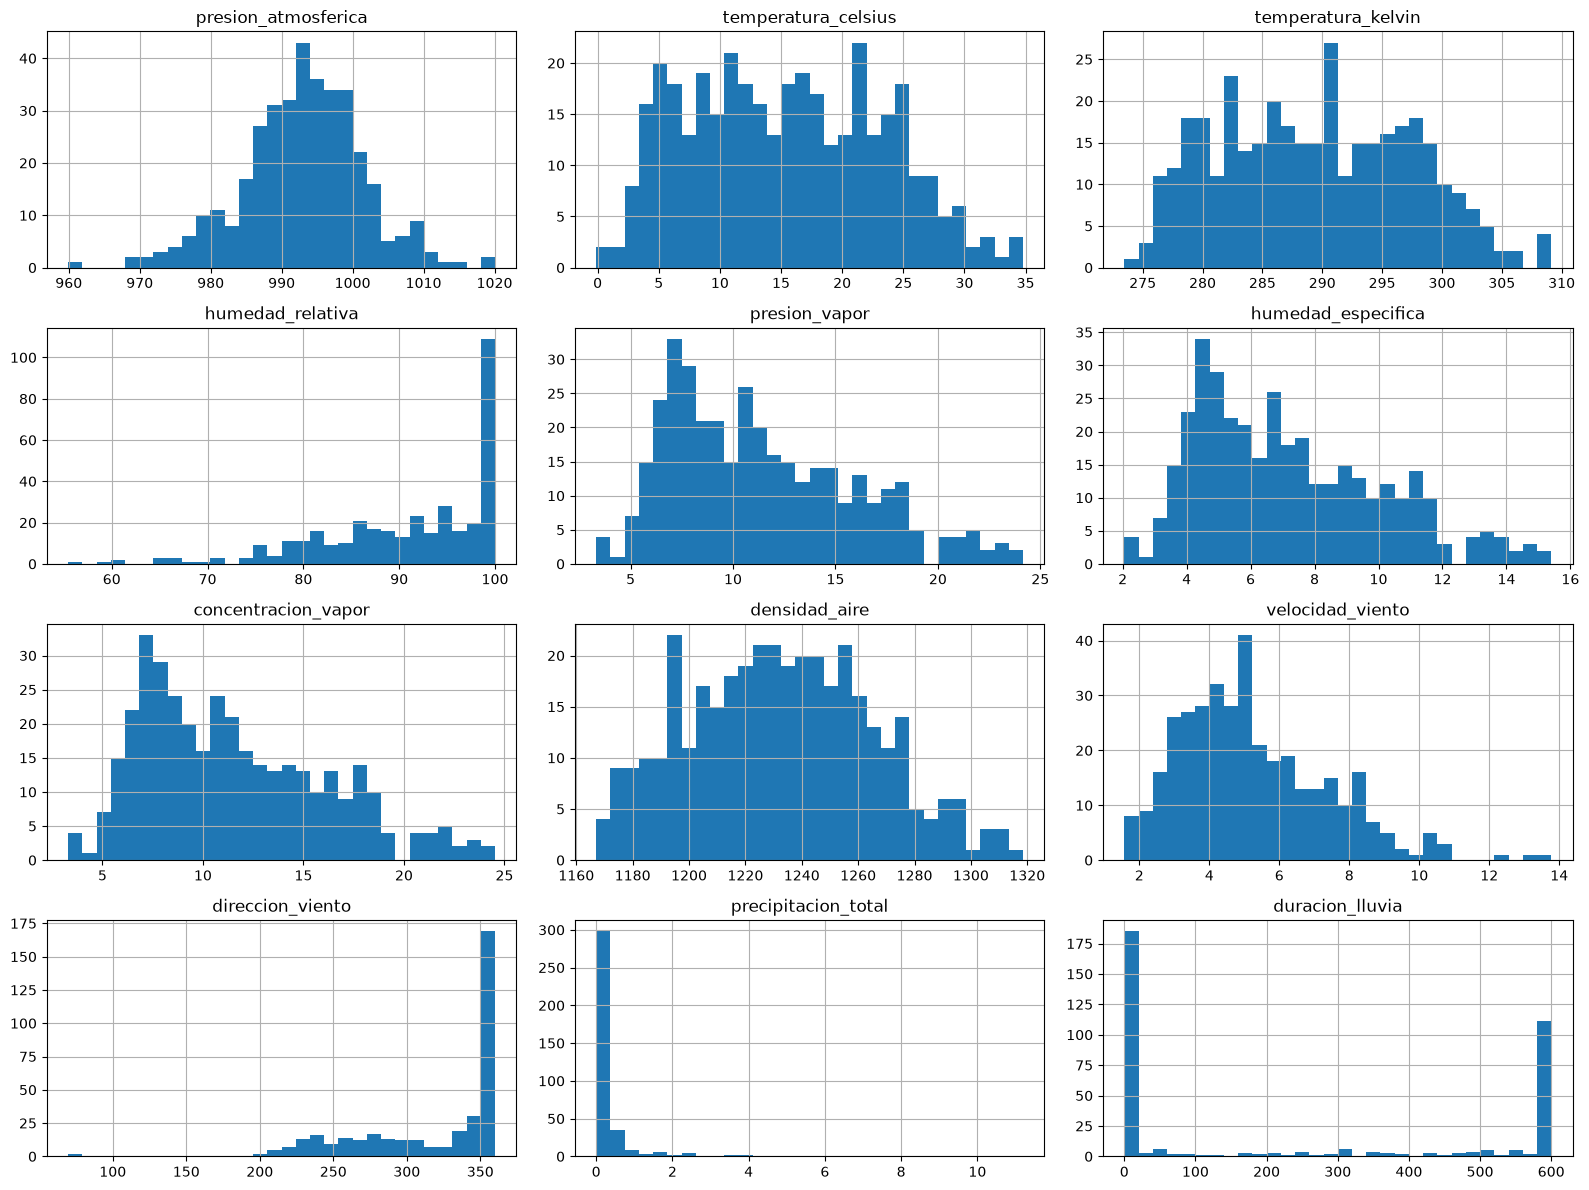

In [22]:
indicadores_diarios.hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

8. Utiliza el dataframe de indicadores diarios para crear un nuevo dataframe `indicadores_mensuales`. Para ello:
- Crea una nueva columna `mes` a partir de la fecha que se encuentra en el índice.
- Haciendo uso de `groupby()`, calcula los promedios mensuales y conserva únicamente las columnas `humedad_relativa`, `temperatura_celsius` y `velocidad_viento` en el nuevo dataframe.

In [23]:
indicadores_diarios['mes'] = pd.to_datetime(indicadores_diarios.index).month
indicadores_diarios.head()

,presion_atmosferica,temperatura_celsius,temperatura_kelvin,humedad_relativa,presion_vapor,humedad_especifica,concentracion_vapor,densidad_aire,velocidad_viento,direccion_viento,precipitacion_total,duracion_lluvia,mes
fecha,,,,,,,,,,,,,
2020-01-01,1008.89,4.58,277.27,95.0,5.81,3.60,5.77,1298.02,1.91,356.9,0.0,0,1
2020-01-02,1004.16,6.47,279.72,93.9,5.57,3.48,5.58,1304.37,2.67,358.8,0.0,0,1
2020-01-03,998.45,8.17,281.80,89.3,9.34,5.86,9.39,1266.97,8.79,336.5,0.2,470,1
2020-01-04,1003.47,6.61,280.15,91.4,8.54,5.36,8.58,1270.10,4.61,354.7,1.0,600,1
2020-01-05,1009.07,4.43,277.01,85.3,6.44,3.99,6.40,1275.47,3.14,274.6,0.0,0,1


In [24]:
indicadores_mensuales = indicadores_diarios.groupby('mes')[['humedad_relativa', 'temperatura_celsius',
                                                            'velocidad_viento']].mean()
indicadores_mensuales

,humedad_relativa,temperatura_celsius,velocidad_viento
mes,,,
1,89.776129,6.821290,5.031935
2,85.719655,8.962414,7.489655
3,85.372903,9.683871,6.421290
4,80.938667,16.879667,4.997000
5,87.464839,17.135484,4.865806
6,94.256000,22.212000,5.296667
7,85.959355,24.336129,4.830323
8,92.002581,26.097742,5.040323
9,97.570000,21.571667,4.153333


9. Construye el mismo dataframe mensual, pero esta vez utilizando la función `pivot_table()`.
- Añade la columna `indice_calor` usando la fórmula de Thom (*Temperature - Humidity Index*, TDI):
> `temperatura_celsius + 0.33 x humedad_relativa - 0.7 x velocidad_viento - 4`

In [25]:
indicadores_mensuales_pivot = indicadores_diarios.pivot_table(index='mes',
                                                          values=['humedad_relativa', 'temperatura_celsius',
                                                                  'velocidad_viento'],
                                                          aggfunc='mean')
indicadores_mensuales_pivot.equals(indicadores_mensuales)

True

El dataframe obtenido con `pivot_table()` es igual al obtenido con `groupby()`: mismo índice (`mes`), mismas columnas y mismos valores.

In [26]:
indicadores_mensuales_pivot['indice_calor'] = (indicadores_mensuales_pivot['temperatura_celsius']
                                               + 0.33 * indicadores_mensuales_pivot['humedad_relativa']
                                               - 0.7 * indicadores_mensuales_pivot['velocidad_viento'] - 4)
indicadores_mensuales_pivot

,humedad_relativa,temperatura_celsius,velocidad_viento,indice_calor
mes,,,,
1,89.776129,6.821290,5.031935,28.925058
2,85.719655,8.962414,7.489655,28.007141
3,85.372903,9.683871,6.421290,29.362026
4,80.938667,16.879667,4.997000,36.091527
5,87.464839,17.135484,4.865806,38.592816
6,94.256000,22.212000,5.296667,45.608813
7,85.959355,24.336129,4.830323,45.321490
8,92.002581,26.097742,5.040323,48.930368
9,97.570000,21.571667,4.153333,46.862433


10. Recuerda que de las cuatro funciones estudiadas para manipular la estructura del dataframe:
- `melt/pivot` hacen las transformaciones de manera controlada, es decir puedes
definir por medio de sus parámetros qué variables quedarán como índices, columnas y valores.
- `stack/unstack` la conversión se aplica siempre sobre los niveles inferiores de index/columns.
- Convierte el dataframe del ejercicio anterior a formato largo usando: `melt()` y `stack()` y comenta las diferencias.

In [27]:
indicadores_melt = indicadores_mensuales_pivot.reset_index().melt(id_vars='mes', var_name='indicador',
                                                               value_name='valor')
indicadores_melt

,mes,indicador,valor
0,1,humedad_relativa,89.776129
1,2,humedad_relativa,85.719655
2,3,humedad_relativa,85.372903
3,4,humedad_relativa,80.938667
4,5,humedad_relativa,87.464839
5,6,humedad_relativa,94.256000
6,7,humedad_relativa,85.959355
7,8,humedad_relativa,92.002581
8,9,humedad_relativa,97.570000
9,10,humedad_relativa,96.950645


In [28]:
indicadores_stack = indicadores_mensuales_pivot.stack()
indicadores_stack

mes                     
1    humedad_relativa       89.776129
     temperatura_celsius     6.821290
     velocidad_viento        5.031935
     indice_calor           28.925058
2    humedad_relativa       85.719655
     temperatura_celsius     8.962414
     velocidad_viento        7.489655
     indice_calor           28.007141
3    humedad_relativa       85.372903
     temperatura_celsius     9.683871
     velocidad_viento        6.421290
     indice_calor           29.362026
4    humedad_relativa       80.938667
     temperatura_celsius    16.879667
     velocidad_viento        4.997000
     indice_calor           36.091527
5    humedad_relativa       87.464839
     temperatura_celsius    17.135484
     velocidad_viento        4.865806
     indice_calor           38.592816
6    humedad_relativa       94.256000
     temperatura_celsius    22.212000
     velocidad_viento        5.296667
     indice_calor           45.608813
7    humedad_relativa       85.959355
     temperatura_celsius 

**Diferencias entre `melt()` y `stack()`:**

*   **Tipo de resultado:** `melt()` devuelve un **DataFrame** con las columnas `mes`, `indicador` y `valor`; `stack()` devuelve una **Series** con un índice jerárquico (`MultiIndex`) formado por `mes` y el nombre del indicador.
*   **Control de la transformación:** en `melt()` se define por medio de sus parámetros qué columnas se conservan como identificadores (`id_vars`) y los nombres de las nuevas columnas (`var_name`, `value_name`). Como `melt()` no conserva el índice, fue necesario convertir `mes` en columna con `reset_index()`. En `stack()` no hay esa elección: siempre mueve el nivel inferior de las columnas al nivel más interno del índice, por lo que `mes` se mantiene en el índice y el nuevo nivel queda sin nombre.
*   **Orden de los registros:** `melt()` agrupa por indicador (los 12 meses de `humedad_relativa`, luego los de `temperatura_celsius`, etc.) con un índice nuevo de 0 a 47; `stack()` agrupa por mes (los 4 indicadores de enero, luego los de febrero, etc.).

En ambos casos se obtienen los mismos 48 valores (12 meses × 4 indicadores), sólo cambia la forma en que se organizan.

---

**Declaración de uso de IA**

*   Anthropic. (2026). *Claude (Opus 5.5)* [Modelo de lenguaje grande], utilizado a través de Claude Code para generación de código y redacción de los análisis. https://claude.ai/

---